# 03 — Churn Classification (Classical)
**Member C — Classification Lead**

Trains six classical classifiers with **5-fold StratifiedKFold + small GridSearch**, applies **SMOTE inside CV folds**, and evaluates on a held-out 20% test set.

**Metrics:** AUC-ROC, F1, Precision, Recall, Accuracy.  Best model + ROC curves + confusion matrices + feature importance go to `reports/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

from src.utils import seed_all, savefig, DATA_PROCESSED, REPORTS_DIR
from src.plot_style import apply_style, PALETTE
from src.features import build_supervised_frame
from src import classification as cls

seed_all(); apply_style()

In [2]:
# Load the LEAKAGE-SAFE feature set (built from transactions strictly before
# CHURN_CUTOFF, snapshot_date = CHURN_CUTOFF) and merge with churn labels.
# Encoding (scaling + country one-hot) is deferred to the pipeline so it is
# fit on training folds only — no pre-split leakage.
feats = pd.read_csv(DATA_PROCESSED / 'classification_features.csv')
churn = pd.read_csv(DATA_PROCESSED / 'churn_labels.csv')
frame = build_supervised_frame(feats, churn)
print(f'Customers: {len(frame):,}  |  raw features: {frame.shape[1] - 2}  |  churn rate: {frame["churn"].mean():.2%}')
print(f'Recency range (pre-cutoff snapshot): [{frame["Recency"].min()}, {frame["Recency"].max()}] days')
frame.head()

Customers: 5,249  |  raw features: 7  |  churn rate: 57.31%
Recency range (pre-cutoff snapshot): [0, 638] days


,CustomerID,Recency,Frequency,Monetary,avg_basket_value,avg_basket_size,unique_products,DominantCountry,churn
0,12346,225,12,505.98,42.165000,16.500000,27,United Kingdom,1
1,12347,29,6,3998.66,666.443333,384.333333,107,Iceland,0
2,12348,148,4,1481.16,370.290000,600.250000,25,Finland,0
3,12349,307,3,2169.04,723.013333,331.000000,90,Italy,0
4,12350,210,1,309.35,309.350000,197.000000,17,Norway,1


## 1. Train all six classical models (CV + held-out test)

In [3]:
outcomes, table, splits, meta = cls.train_classical(frame)
feat_names = meta['transformed_feature_names']
table.to_csv(REPORTS_DIR / 'classical_results.csv', index=False)
print(f"Best model: {meta['best_model_name']}  (test AUC {meta['best_model_auc']:.4f})")
table

  -> LogisticRegression ...

 CV-AUC=0.7987  Test-AUC=0.7850
  -> DecisionTree ...

 CV-AUC=0.7748  Test-AUC=0.7484
  -> RandomForest ...

 CV-AUC=0.7999  Test-AUC=0.7816
  -> KNN ...

 CV-AUC=0.7794  Test-AUC=0.7675
  -> SVM_RBF ...

 CV-AUC=0.7846  Test-AUC=0.7595
  -> GaussianNB ...

 CV-AUC=0.7741  Test-AUC=0.7601
Best model: LogisticRegression  (test AUC 0.7850)


,Model,CV_AUC_mean,CV_AUC_std,AUC,F1,Precision,Recall,Accuracy,best_params
0,LogisticRegression,0.7987,0.0161,0.7850,0.7392,0.7698,0.7110,0.7124,{'clf__C': 0.1}
1,RandomForest,0.7999,0.0177,0.7816,0.7454,0.7467,0.7442,0.7086,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
2,KNN,0.7794,0.0177,0.7675,0.7206,0.7395,0.7027,0.6876,{'clf__n_neighbors': 21}
3,GaussianNB,0.7741,0.0145,0.7601,0.7441,0.7237,0.7658,0.6981,{}
4,SVM_RBF,0.7846,0.0198,0.7595,0.7450,0.7525,0.7375,0.7105,"{'clf__C': 1.0, 'clf__gamma': 'scale'}"
5,DecisionTree,0.7748,0.0120,0.7484,0.7237,0.7536,0.6960,0.6952,"{'clf__max_depth': 6, 'clf__min_samples_leaf': 5}"


## 2. Held-out ROC curves — all models on one axis

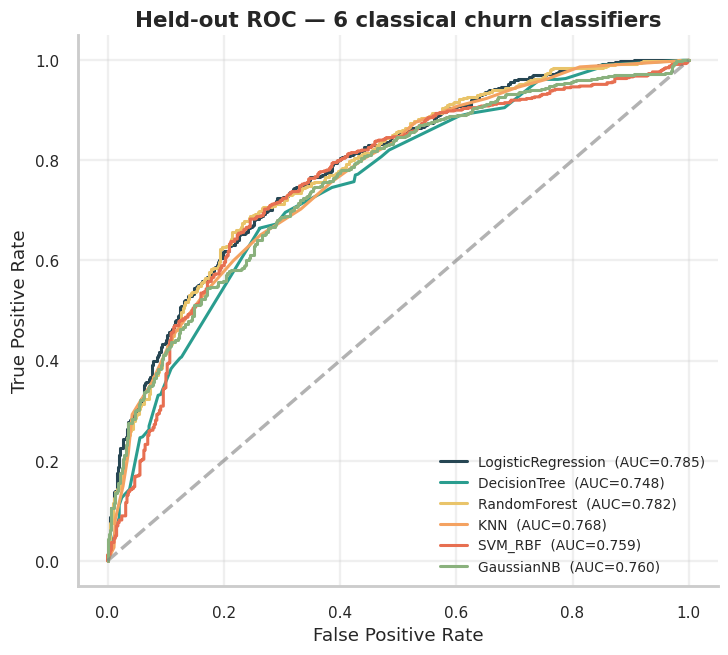

In [4]:
X_te, y_te = splits['X_test_raw'], splits['y_test']
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for o, color in zip(outcomes, PALETTE):
    try:
        proba = o.estimator.predict_proba(X_te)[:, 1]
    except AttributeError:
        proba = o.estimator.decision_function(X_te)
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{o.name}  (AUC={o.test_metrics['AUC']:.3f})")
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Held-out ROC — 6 classical churn classifiers')
ax.legend(loc='lower right', fontsize=9)
savefig(fig, '03_roc_classical'); plt.show()

## 3. Confusion matrix of the best model

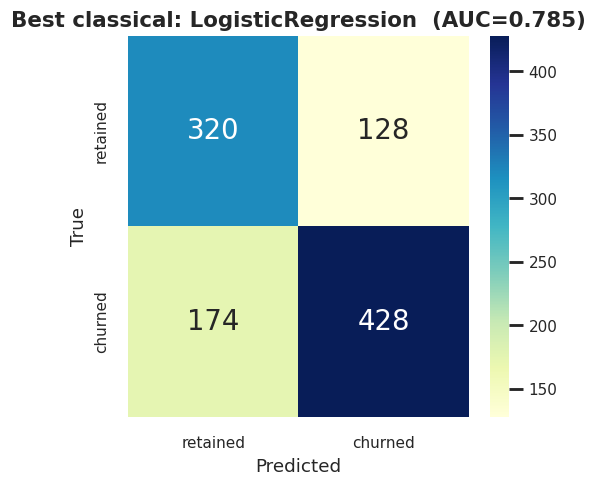

Best params: {'clf__C': 0.1}


In [5]:
best = max(outcomes, key=lambda o: o.test_metrics['AUC'])
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(best.confusion, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['retained','churned'], yticklabels=['retained','churned'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Best classical: {best.name}  (AUC={best.test_metrics["AUC"]:.3f})')
savefig(fig, '03_cm_best'); plt.show()
print('Best params:', best.best_params)

## 4. Feature importance from RandomForest

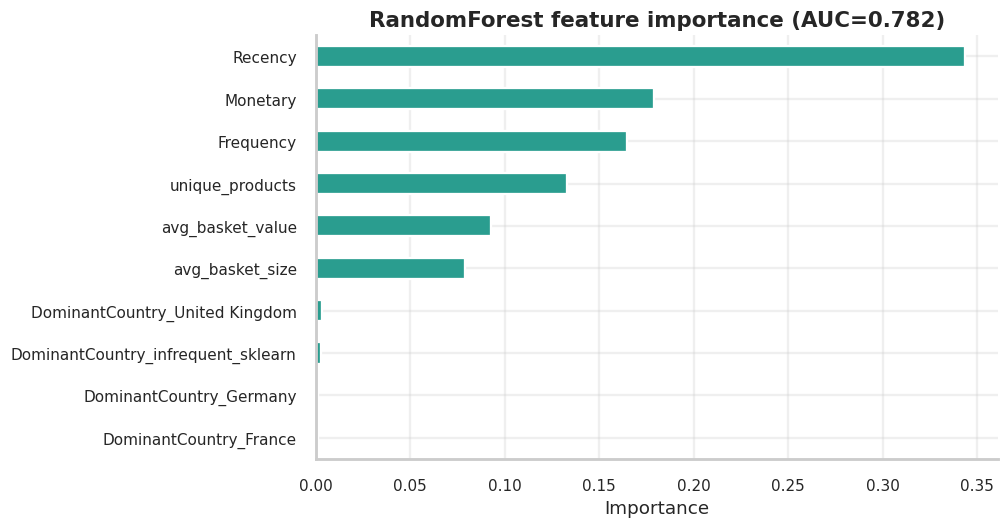

In [6]:
rf = next(o for o in outcomes if o.name == 'RandomForest')
rf_clf = rf.estimator.named_steps['clf']
imp = pd.Series(rf_clf.feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color=PALETTE[1])
ax.set_title(f'RandomForest feature importance (AUC={rf.test_metrics["AUC"]:.3f})')
ax.set_xlabel('Importance')
savefig(fig, '03_rf_importance'); plt.show()

## 5. Save trained models

In [7]:
cls.save_models(outcomes)

  saved LogisticRegression.joblib
  saved DecisionTree.joblib
  saved RandomForest.joblib
  saved KNN.joblib
  saved SVM_RBF.joblib
  saved GaussianNB.joblib


In [8]:
import joblib
# Persist the full split bundle (raw + transformed matrices, fitted preprocessor,
# feature names) for the DL / SHAP notebook so it reuses the exact same split.
joblib.dump(splits, DATA_PROCESSED / 'splits.joblib')
print('Wrote splits.joblib for downstream notebooks (DL, SHAP).')

Wrote splits.joblib for downstream notebooks (DL, SHAP).
